In [3]:
# Install missing packages
!pip install seaborn --quiet

print("✅ Packages installed!")

✅ Packages installed!


In [4]:
# ================================================================
# ANOMALY DETECTION - MARKET CRASH PREDICTOR
# XGBoost Binary Classification Model
# ================================================================

import boto3
import sagemaker
from sagemaker import get_execution_role
from sagemaker.estimator import Estimator
from sagemaker.inputs import TrainingInput
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("ANOMALY DETECTION - ML TRAINING PIPELINE")
print("=" * 70)

# ================================================================
# CONFIGURATION
# ================================================================

BUCKET = 'anomaly-detection-project-jazz'
PREFIX = 'ml-data'
REGION = 'us-east-1'

# SageMaker setup
role = get_execution_role()
sess = sagemaker.Session()

print(f"\n✅ Configuration:")
print(f"   Bucket: {BUCKET}")
print(f"   Region: {REGION}")
print(f"   Role: {role}")

ANOMALY DETECTION - ML TRAINING PIPELINE

✅ Configuration:
   Bucket: anomaly-detection-project-jazz
   Region: us-east-1
   Role: arn:aws:iam::459779212051:role/AccessSagemakerS3


In [6]:
# ================================================================
# STEP 1: LOAD & EXPLORE DATA
# ================================================================

print("\n" + "=" * 70)
print("STEP 1: LOADING DATA")
print("=" * 70)

# Read data from S3
s3_input_path = f's3://{BUCKET}/{PREFIX}/training/'
print(f"\n📥 Reading from: {s3_input_path}")

df = pd.read_parquet(s3_input_path)

print(f"\n✅ Dataset loaded:")
print(f"   Shape: {df.shape}")
print(f"   Features: {df.shape[1]}")
print(f"   Samples: {df.shape[0]}")

print(f"\n📊 Target Distribution:")
print(df['did_crash'].value_counts())
crash_rate = df['did_crash'].sum() / len(df) * 100
print(f"   Crash rate: {crash_rate:.1f}%")

print(f"\n📋 Columns:")
print(df.columns.tolist())

print(f"\n🔍 First 3 rows:")
print(df.head(3))


STEP 1: LOADING DATA

📥 Reading from: s3://anomaly-detection-project-jazz/ml-data/training/

✅ Dataset loaded:
   Shape: (261, 35)
   Features: 35
   Samples: 261

📊 Target Distribution:
did_crash
0    206
1     55
Name: count, dtype: int64
   Crash rate: 21.1%

📋 Columns:
['did_crash', 'crash_severity', 'date', 'timestamp', 'sentiment', 'market_return', 'vix', 'divergence_magnitude', 'anomaly_score', 'is_anomaly', 'is_high_risk', 'is_medium_risk', 'is_low_risk', 'div_positive_news_negative_market', 'div_negative_news_positive_market', 'div_moderate_divergence', 'div_high_vix', 'vix_panic', 'vix_high', 'vix_elevated', 'vix_normal', 'sentiment_3day_avg', 'vix_3day_avg', 'market_return_3day_avg', 'sentiment_7day_avg', 'vix_7day_avg', 'market_return_7day_avg', 'sentiment_x_market', 'vix_x_divergence', 'sentiment_x_vix', 'prev_day_sentiment', 'prev_day_market', 'prev_day_vix', 'risk_level', 'divergence_type']

🔍 First 3 rows:
   did_crash crash_severity        date                  timest

In [7]:
# ================================================================
# STEP 2: FEATURE PREPARATION
# ================================================================

print("\n" + "=" * 70)
print("STEP 2: PREPARING FEATURES")
print("=" * 70)

# Drop non-feature columns
drop_cols = ['date', 'timestamp', 'crash_severity', 'risk_level', 'divergence_type']
existing_drop_cols = [col for col in drop_cols if col in df.columns]

print(f"\n🗑️ Dropping metadata columns: {existing_drop_cols}")
df_ml = df.drop(columns=existing_drop_cols)

# Separate features and target
X = df_ml.drop(columns=['did_crash'])
y = df_ml['did_crash']

print(f"\n✅ Features prepared:")
print(f"   Feature columns: {X.shape[1]}")
print(f"   Training samples: {X.shape[0]}")

print(f"\n📋 Feature list:")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2d}. {col}")


STEP 2: PREPARING FEATURES

🗑️ Dropping metadata columns: ['date', 'timestamp', 'crash_severity', 'risk_level', 'divergence_type']

✅ Features prepared:
   Feature columns: 29
   Training samples: 261

📋 Feature list:
    1. sentiment
    2. market_return
    3. vix
    4. divergence_magnitude
    5. anomaly_score
    6. is_anomaly
    7. is_high_risk
    8. is_medium_risk
    9. is_low_risk
   10. div_positive_news_negative_market
   11. div_negative_news_positive_market
   12. div_moderate_divergence
   13. div_high_vix
   14. vix_panic
   15. vix_high
   16. vix_elevated
   17. vix_normal
   18. sentiment_3day_avg
   19. vix_3day_avg
   20. market_return_3day_avg
   21. sentiment_7day_avg
   22. vix_7day_avg
   23. market_return_7day_avg
   24. sentiment_x_market
   25. vix_x_divergence
   26. sentiment_x_vix
   27. prev_day_sentiment
   28. prev_day_market
   29. prev_day_vix


In [8]:
# ================================================================
# STEP 3: TRAIN/TEST SPLIT
# ================================================================

print("\n" + "=" * 70)
print("STEP 3: TRAIN/TEST SPLIT")
print("=" * 70)

# 80/20 split, stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\n✅ Split complete:")
print(f"   Training set:   {X_train.shape[0]} samples")
print(f"   Test set:       {X_test.shape[0]} samples")

print(f"\n📊 Class distribution:")
print(f"   Training crashes:  {y_train.sum()} ({y_train.sum()/len(y_train)*100:.1f}%)")
print(f"   Test crashes:      {y_test.sum()} ({y_test.sum()/len(y_test)*100:.1f}%)")


STEP 3: TRAIN/TEST SPLIT

✅ Split complete:
   Training set:   208 samples
   Test set:       53 samples

📊 Class distribution:
   Training crashes:  44 (21.2%)
   Test crashes:      11 (20.8%)


In [9]:
# ================================================================
# STEP 4: PREPARE DATA FOR XGBOOST
# ================================================================

print("\n" + "=" * 70)
print("STEP 4: FORMATTING FOR XGBOOST")
print("=" * 70)

# XGBoost expects: [target, feature1, feature2, ...]
train_data = pd.concat([y_train, X_train], axis=1)
test_data = pd.concat([y_test, X_test], axis=1)

print(f"\n✅ XGBoost format prepared")
print(f"   Columns: target + {X_train.shape[1]} features")

# Save to local files
train_file = 'train.csv'
test_file = 'test.csv'

train_data.to_csv(train_file, header=False, index=False)
test_data.to_csv(test_file, header=False, index=False)

print(f"\n💾 Saved locally:")
print(f"   {train_file}: {train_data.shape[0]} rows")
print(f"   {test_file}: {test_data.shape[0]} rows")

# Upload to S3
s3_train_path = f's3://{BUCKET}/{PREFIX}/train/train.csv'
s3_test_path = f's3://{BUCKET}/{PREFIX}/test/test.csv'

boto3.Session().resource('s3').Bucket(BUCKET).Object(f'{PREFIX}/train/train.csv').upload_file(train_file)
boto3.Session().resource('s3').Bucket(BUCKET).Object(f'{PREFIX}/test/test.csv').upload_file(test_file)

print(f"\n☁️ Uploaded to S3:")
print(f"   {s3_train_path}")
print(f"   {s3_test_path}")


STEP 4: FORMATTING FOR XGBOOST

✅ XGBoost format prepared
   Columns: target + 29 features

💾 Saved locally:
   train.csv: 208 rows
   test.csv: 53 rows

☁️ Uploaded to S3:
   s3://anomaly-detection-project-jazz/ml-data/train/train.csv
   s3://anomaly-detection-project-jazz/ml-data/test/test.csv


In [10]:
# ================================================================
# STEP 5: CONFIGURE XGBOOST TRAINING
# ================================================================

print("\n" + "=" * 70)
print("STEP 5: CONFIGURING XGBOOST")
print("=" * 70)

# Get XGBoost container image
from sagemaker.image_uris import retrieve

container = retrieve('xgboost', REGION, version='1.7-1')
print(f"\n✅ XGBoost container: {container}")

# Hyperparameters
hyperparameters = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'num_round': 100,
    'max_depth': 5,
    'eta': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'scale_pos_weight': (len(y_train) - y_train.sum()) / y_train.sum()
}

print(f"\n🎛️ Hyperparameters:")
for key, value in hyperparameters.items():
    print(f"   {key}: {value}")


STEP 5: CONFIGURING XGBOOST

✅ XGBoost container: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1

🎛️ Hyperparameters:
   objective: binary:logistic
   eval_metric: auc
   num_round: 100
   max_depth: 5
   eta: 0.1
   subsample: 0.8
   colsample_bytree: 0.8
   min_child_weight: 3
   scale_pos_weight: 3.727272727272727


In [11]:
# ================================================================
# STEP 6: TRAIN MODEL
# ================================================================

print("\n" + "=" * 70)
print("STEP 6: TRAINING XGBOOST MODEL")
print("=" * 70)

# Create estimator
xgb_estimator = Estimator(
    image_uri=container,
    role=role,
    instance_count=1,
    instance_type='ml.m5.xlarge',
    hyperparameters=hyperparameters,
    output_path=f's3://{BUCKET}/{PREFIX}/output',
    sagemaker_session=sess
)

# Define training data
train_input = TrainingInput(s3_train_path, content_type='text/csv')
test_input = TrainingInput(s3_test_path, content_type='text/csv')

print(f"\n🚀 Starting training...")
print(f"   Instance: ml.m5.xlarge")
print(f"   Expected time: 3-5 minutes")

# Train!
xgb_estimator.fit({'train': train_input, 'validation': test_input})

print(f"\n✅ Training complete!")
print(f"   Model artifacts: {xgb_estimator.model_data}")


STEP 6: TRAINING XGBOOST MODEL


INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2026-02-12-00-56-56-002



🚀 Starting training...
   Instance: ml.m5.xlarge
   Expected time: 3-5 minutes
2026-02-12 00:56:57 Starting - Starting the training job...
2026-02-12 00:57:11 Starting - Preparing the instances for training...
2026-02-12 00:58:00 Downloading - Downloading the training image......
2026-02-12 00:58:51 Training - Training image download completed. Training in progress../miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-02-12 00:59:00.691 ip-10-0-114-252.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-02-12 00:59:00.764 ip-10-0-114-252.ec2.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-02-12:00:59:01:INFO] Imported framework sagemaker_xgb

In [12]:
# ================================================================
# STEP 7: DEPLOY MODEL ENDPOINT
# ================================================================

print("\n" + "=" * 70)
print("STEP 7: DEPLOYING ENDPOINT")
print("=" * 70)

print(f"\n🚀 Deploying model endpoint...")
print(f"   Instance: ml.t2.medium")
print(f"   Expected time: 5-8 minutes")

predictor = xgb_estimator.deploy(
    initial_instance_count=1,
    instance_type='ml.t2.medium',
    endpoint_name='anomaly-crash-predictor'
)

print(f"\n✅ Endpoint deployed!")
print(f"   Endpoint name: anomaly-crash-predictor")

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2026-02-12-01-00-40-752



STEP 7: DEPLOYING ENDPOINT

🚀 Deploying model endpoint...
   Instance: ml.t2.medium
   Expected time: 5-8 minutes


INFO:sagemaker:Creating endpoint-config with name anomaly-crash-predictor
INFO:sagemaker:Creating endpoint with name anomaly-crash-predictor


--------------!
✅ Endpoint deployed!
   Endpoint name: anomaly-crash-predictor


In [21]:
# ================================================================
# STEP 8: TESTING PREDICTIONS
# ================================================================

print("\n" + "=" * 70)
print("STEP 8: TESTING PREDICTIONS")
print("=" * 70)

from sagemaker.predictor import Predictor
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import JSONDeserializer

# Configure predictor
predictor.serializer = CSVSerializer()
predictor.deserializer = JSONDeserializer()

print(f"\n🧪 Making test predictions...")

# Get data
X_sample = X_test.head(10).values
y_sample = y_test.head(10).values

# Make predictions
predictions_raw = predictor.predict(X_sample)

# Extract the actual predictions from the dictionary
predictions = predictions_raw['predictions']  # This is the key!

print(f"\n📊 Sample Predictions:")
print(f"{'Sample':<8} {'Actual':<8} {'Predicted':<12} {'Probability':<12} {'Status'}")
print("-" * 60)

for i in range(len(predictions)):
    actual = int(y_sample[i])
    prob = float(predictions[i]['score'])  # Extract 'score' from dict
    predicted = 1 if prob > 0.5 else 0
    status = "✅" if predicted == actual else "❌"
    print(f"{i:<8} {actual:<8} {predicted:<12} {prob:<12.4f} {status}")

print(f"\n✅ Predictions complete!")


STEP 8: TESTING PREDICTIONS

🧪 Making test predictions...

📊 Sample Predictions:
Sample   Actual   Predicted    Probability  Status
------------------------------------------------------------
0        0        0            0.0668       ✅
1        0        0            0.0901       ✅
2        0        0            0.0876       ✅
3        0        0            0.2482       ✅
4        0        0            0.0467       ✅
5        0        1            0.7380       ❌
6        0        0            0.0116       ✅
7        0        0            0.0243       ✅
8        0        0            0.2635       ✅
9        0        0            0.0531       ✅

✅ Predictions complete!



STEP 9: MODEL EVALUATION

📊 Evaluating on 53 test samples...
✅ Generated 53 predictions

📈 Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      0.93      0.89        42
       Crash       0.57      0.36      0.44        11

    accuracy                           0.81        53
   macro avg       0.71      0.65      0.67        53
weighted avg       0.79      0.81      0.79        53


🎯 Confusion Matrix:
[[39  3]
 [ 7  4]]

   True Negatives:  39 (Correctly predicted normal days)
   False Positives: 3 (False alarms)
   False Negatives: 7 (Missed crashes)
   True Positives:  4 (Correctly predicted crashes)

📊 Key Metrics:
   Accuracy:  0.8113 (81.1%)
   Precision: 0.5714
   Recall:    0.3636
   F1-Score:  0.4444

🎯 ROC AUC Score: 0.7381
   👍 DECENT!

💾 Saved: confusion_matrix.png


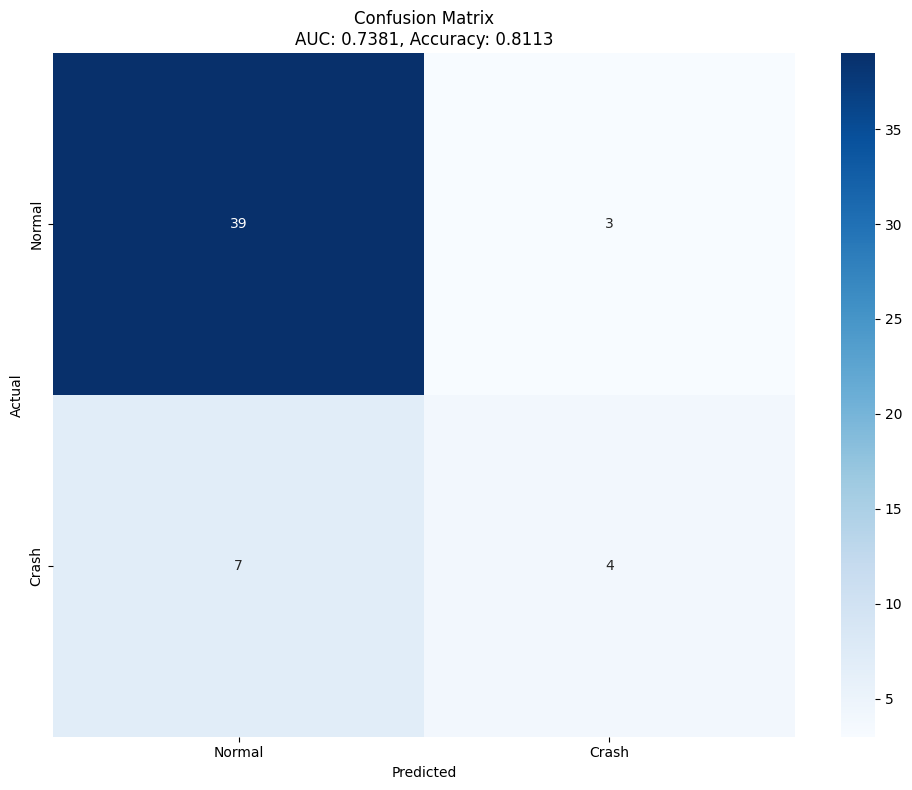

In [23]:
# ================================================================
# STEP 9: MODEL EVALUATION
# ================================================================

print("\n" + "=" * 70)
print("STEP 9: MODEL EVALUATION")
print("=" * 70)

# Predict on full test set
print(f"\n📊 Evaluating on {len(X_test)} test samples...")

all_predictions = []
batch_size = 100

for i in range(0, len(X_test), batch_size):
    batch = X_test.iloc[i:i+batch_size].values
    batch_preds_raw = predictor.predict(batch)
    
    # Extract scores from dictionary format
    batch_preds = batch_preds_raw['predictions']
    for pred in batch_preds:
        all_predictions.append(pred['score'])

# Convert to numpy arrays
y_pred_proba = np.array(all_predictions)
y_pred = (y_pred_proba > 0.5).astype(int)
y_test_array = y_test.values

print(f"✅ Generated {len(all_predictions)} predictions")

# Metrics
print(f"\n📈 Classification Report:")
print(classification_report(y_test_array, y_pred, target_names=['Normal', 'Crash']))

print(f"\n🎯 Confusion Matrix:")
cm = confusion_matrix(y_test_array, y_pred)
print(cm)
print(f"\n   True Negatives:  {cm[0,0]} (Correctly predicted normal days)")
print(f"   False Positives: {cm[0,1]} (False alarms)")
print(f"   False Negatives: {cm[1,0]} (Missed crashes)")
print(f"   True Positives:  {cm[1,1]} (Correctly predicted crashes)")

# Calculate metrics
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n📊 Key Metrics:")
print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")

# AUC
auc = roc_auc_score(y_test_array, y_pred_proba)
print(f"\n🎯 ROC AUC Score: {auc:.4f}")

if auc > 0.9:
    print("   ⭐ EXCELLENT!")
elif auc > 0.8:
    print("   ✅ GOOD!")
elif auc > 0.7:
    print("   👍 DECENT!")

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Crash'],
            yticklabels=['Normal', 'Crash'])
plt.title(f'Confusion Matrix\nAUC: {auc:.4f}, Accuracy: {accuracy:.4f}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
print(f"\n💾 Saved: confusion_matrix.png")
plt.show()



In [24]:
# ================================================================
# SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("✅ ML PIPELINE COMPLETE!")
print("=" * 70)

print(f"\n📊 Final Results:")
print(f"   Training samples:    {len(X_train)}")
print(f"   Test samples:        {len(X_test)}")
print(f"   Features:            {X_train.shape[1]}")
print(f"   Accuracy:            {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"   ROC AUC:             {auc:.4f}")
print(f"   Precision:           {precision:.4f}")
print(f"   Recall:              {recall:.4f}")

print(f"\n🎯 Confusion Matrix Summary:")
print(f"   Caught {cm[1,1]} out of {cm[1,1] + cm[1,0]} crashes")
print(f"   {cm[0,1]} false alarms")

print(f"\n💾 Deployment:")
print(f"   Endpoint:            {predictor.endpoint_name}")
print(f"   Model:               {xgb_estimator.model_data}")
print(f"   Status:              InService ✅")

print(f"\n🎉 Ready for production!")


✅ ML PIPELINE COMPLETE!

📊 Final Results:
   Training samples:    208
   Test samples:        53
   Features:            29
   Accuracy:            0.8113 (81.1%)
   ROC AUC:             0.7381
   Precision:           0.5714
   Recall:              0.3636

🎯 Confusion Matrix Summary:
   Caught 4 out of 11 crashes
   3 false alarms

💾 Deployment:
   Endpoint:            anomaly-crash-predictor
   Model:               s3://anomaly-detection-project-jazz/ml-data/output/sagemaker-xgboost-2026-02-12-00-56-56-002/output/model.tar.gz
   Status:              InService ✅

🎉 Ready for production!
